In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Visualización de los datos importantes para la predicción

## Goles a favor contra número de victorias cada año

### Cargar los datos de una temporada

In [2]:
dataframe_liga = pd.read_csv("Datos_Formateados/SP1-1314.csv")

### Conseguir los equipos de esa temporada

In [3]:
def get_equipos(dataframe: pd.DataFrame) -> list:
    list = []
    for idx in dataframe.index:
        if dataframe['HomeTeam'][idx] not in list:
            list.append(dataframe['HomeTeam'][idx])
        if dataframe['AwayTeam'][idx] not in list:
            list.append(dataframe['AwayTeam'][idx])
    return list

equipos = get_equipos(dataframe=dataframe_liga)
len(equipos)

20

### Conseguir el número de goles a favor de la temporada de cada equipo

In [4]:
def get_goles_a_favor(dataframe: pd.DataFrame, equipo: str) -> int:
    goles_local = dataframe.loc[dataframe['HomeTeam'] == equipo, 'FTHG'].sum()
    goles_visitante = dataframe.loc[dataframe['AwayTeam'] == equipo, 'FTAG'].sum()
    return goles_local + goles_visitante

for equipo in equipos:
    goles = get_goles_a_favor(dataframe=dataframe_liga, equipo=equipo)
    #print("El "+equipo+" ha marcado: "+str(goles)+" goles")

### Conseguir el número de victorias de cada equipo

In [5]:
def get_victorias(dataframe: pd.DataFrame, equipo: str) -> int:
    victorias_local = len(dataframe[(dataframe['HomeTeam'] == equipo) & (dataframe['FTR'] == 'H')])
    victorias_visitante = len(dataframe[(dataframe['AwayTeam'] == equipo) & (dataframe['FTR'] == 'A')])
    empates_local = len(dataframe[(dataframe['HomeTeam'] == equipo) & (dataframe['FTR'] == 'D')])
    empates_visitante = len(dataframe[(dataframe['AwayTeam'] == equipo) & (dataframe['FTR'] == 'D')])
    return victorias_local + victorias_visitante

for equipo in equipos:
    victorias = get_victorias(dataframe=dataframe_liga, equipo=equipo)
    #print("El "+equipo+" ha ganado: "+str(victorias)+" partidos")

### Graficar los datos

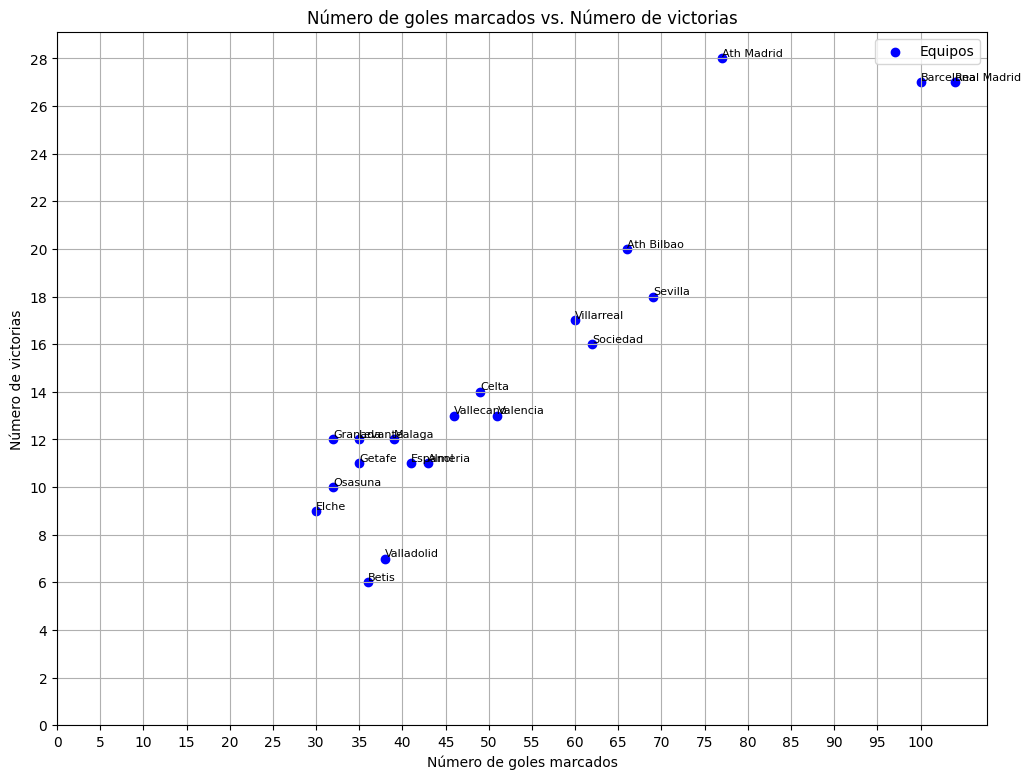

In [6]:
equipos = get_equipos(dataframe=dataframe_liga)
goles_marcados_todos_equipos = []
victorias_todos_equipos = []
for equipo in equipos:
    goles_marcados_todos_equipos.append(get_goles_a_favor(dataframe=dataframe_liga, equipo=equipo))
    victorias_todos_equipos.append(get_victorias(dataframe=dataframe_liga, equipo=equipo))
maximos_goles = max(goles_marcados_todos_equipos)
maximas_victorias = max(victorias_todos_equipos)

plt.figure(figsize=(12, 9))
plt.scatter(goles_marcados_todos_equipos, victorias_todos_equipos, color='blue', label='Equipos')  # Puntos en la gráfica para cada equipo
for i, equipo in enumerate(equipos):
    plt.text(goles_marcados_todos_equipos[i], victorias_todos_equipos[i], equipo, fontsize=8, ha='left', va='bottom')
plt.xlabel('Número de goles marcados')
plt.ylabel('Número de victorias')
plt.title('Número de goles marcados vs. Número de victorias')
plt.xticks(range(0, maximos_goles+1, 5))  # Definir los límites y el paso del eje x
plt.yticks(range(0, maximas_victorias+1, 2))  # Definir los límites y el paso del eje y
plt.grid(True)
plt.legend()
plt.show()

## Goles en contra vs victorias cada año

### Conseguir goles en contra de cada equipo cada año

In [7]:
def get_goles_en_contra(dataframe: pd.DataFrame, equipo: str) -> int:
    goles_encajados_local = dataframe.loc[dataframe['HomeTeam'] == equipo, 'FTAG'].sum()
    goles_encajados_visitante = dataframe.loc[dataframe['AwayTeam'] == equipo, 'FTHG'].sum()
    return goles_encajados_local + goles_encajados_visitante

for equipo in equipos:
    goles = get_goles_en_contra(dataframe=dataframe_liga, equipo=equipo)
    #print("El "+equipo+" ha encajado: "+str(goles)+" goles")

### Graficar los datos

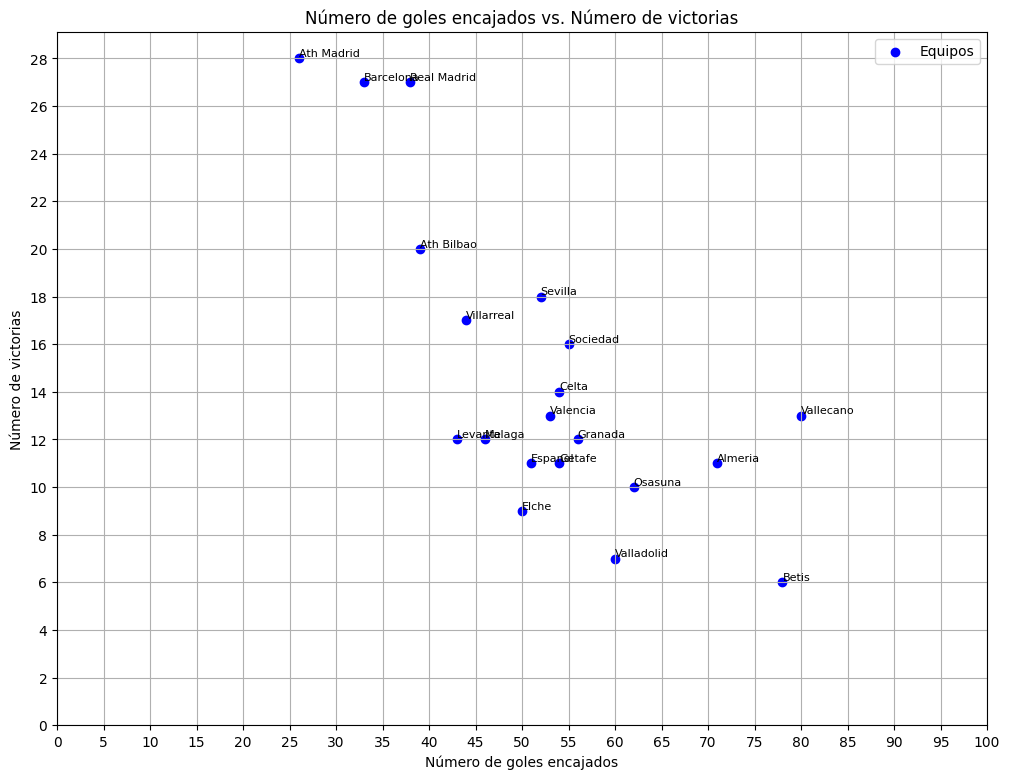

In [8]:
equipos = get_equipos(dataframe=dataframe_liga)
goles_encajados_todos_equipos = []
victorias_todos_equipos = []
for equipo in equipos:
    goles_encajados_todos_equipos.append(get_goles_en_contra(dataframe=dataframe_liga, equipo=equipo))
    victorias_todos_equipos.append(get_victorias(dataframe=dataframe_liga, equipo=equipo))
maximos_goles = max(goles_marcados_todos_equipos)
maximas_victorias = max(victorias_todos_equipos)

plt.figure(figsize=(12, 9))
plt.scatter(goles_encajados_todos_equipos, victorias_todos_equipos, color='blue', label='Equipos')  # Puntos en la gráfica para cada equipo
for i, equipo in enumerate(equipos):
    plt.text(goles_encajados_todos_equipos[i], victorias_todos_equipos[i], equipo, fontsize=8, ha='left', va='bottom')
plt.xlabel('Número de goles encajados')
plt.ylabel('Número de victorias')
plt.title('Número de goles encajados vs. Número de victorias')
plt.xticks(range(0, maximos_goles+1, 5))  # Definir los límites y el paso del eje x
plt.yticks(range(0, maximas_victorias+1, 2))  # Definir los límites y el paso del eje y
plt.grid(True)
plt.legend()
plt.show()

## Fusionar ambos datos

### Primera aproximación: Gol Average

In [9]:
def get_gol_average(dataframe: pd.DataFrame, equipo: str) -> int:
    goles_a_favor = get_goles_a_favor(dataframe=dataframe, equipo=equipo)
    goles_en_contra = get_goles_en_contra(dataframe=dataframe, equipo=equipo)
    return goles_a_favor - goles_en_contra

for equipo in equipos:
    gol_average = get_gol_average(dataframe=dataframe_liga, equipo=equipo)
    #print("El "+equipo+" tiene un gol average de: "+str(gol_average))

### Graficar los datos

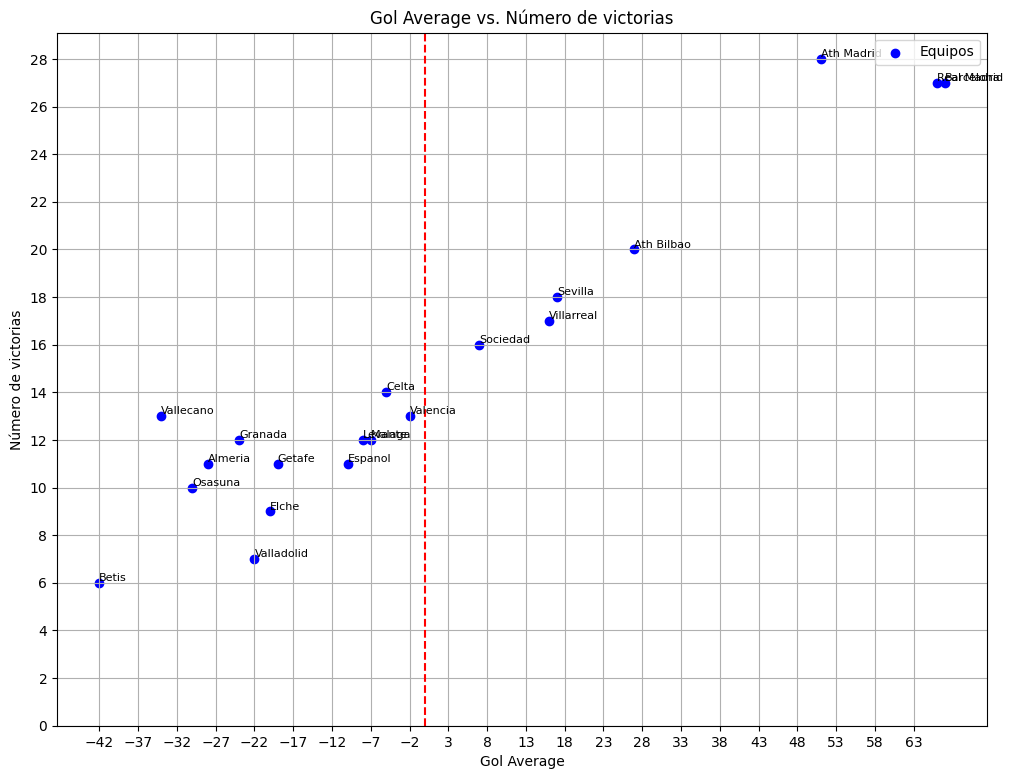

In [10]:
equipos = get_equipos(dataframe=dataframe_liga)
gol_average_todos_equipos = []
victorias_todos_equipos = []
for equipo in equipos:
    gol_average_todos_equipos.append(get_gol_average(dataframe=dataframe_liga, equipo=equipo))
    victorias_todos_equipos.append(get_victorias(dataframe=dataframe_liga, equipo=equipo))
minimo_goles = min(gol_average_todos_equipos)
maximos_goles = max(gol_average_todos_equipos)
maximas_victorias = max(victorias_todos_equipos)

plt.figure(figsize=(12, 9))
plt.scatter(gol_average_todos_equipos, victorias_todos_equipos, color='blue', label='Equipos')  # Puntos en la gráfica para cada equipo
for i, equipo in enumerate(equipos):
    plt.text(gol_average_todos_equipos[i], victorias_todos_equipos[i], equipo, fontsize=8, ha='left', va='bottom')
plt.axvline(x=0, color='red', linestyle='--')
plt.xlabel('Gol Average')
plt.ylabel('Número de victorias')
plt.title('Gol Average vs. Número de victorias')
plt.xticks(range(minimo_goles, maximos_goles+1, 5))  # Definir los límites y el paso del eje x
plt.yticks(range(0, maximas_victorias+1, 2))  # Definir los límites y el paso del eje y
plt.grid(True)
plt.legend()
plt.show()

### Segunda aproximación: media de goles marcados por partido

In [11]:
def get_media_goles_marcados(dataframe: pd.DataFrame, equipo: str) -> float:
    goles_marcados = get_goles_a_favor(dataframe=dataframe, equipo=equipo)
    equipos = get_equipos(dataframe=dataframe)
    partidos_jugados = 2 * len(dataframe) / len(equipos)
    return goles_marcados / partidos_jugados

for equipo in equipos:
    media_goles_marcados = get_media_goles_marcados(dataframe=dataframe_liga, equipo=equipo)
    #print("El "+equipo+" tiene una media de goles marcados por partido de: "+str(media_goles_marcados))

### Graficar datos

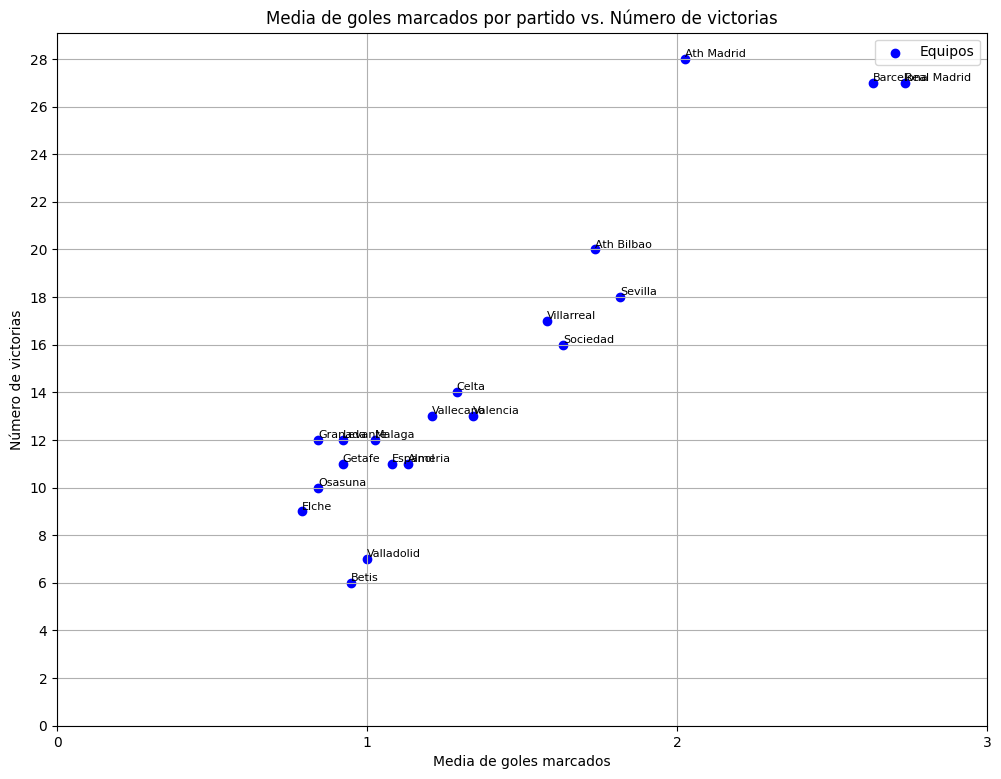

In [12]:
equipos = get_equipos(dataframe=dataframe_liga)
media_goles_todos_equipos = []
victorias_todos_equipos = []
for equipo in equipos:
    media_goles_todos_equipos.append(get_media_goles_marcados(dataframe=dataframe_liga, equipo=equipo))
    victorias_todos_equipos.append(get_victorias(dataframe=dataframe_liga, equipo=equipo))
maximos_goles = max(media_goles_todos_equipos)
maximas_victorias = max(victorias_todos_equipos)

plt.figure(figsize=(12, 9))
plt.scatter(media_goles_todos_equipos, victorias_todos_equipos, color='blue', label='Equipos')  # Puntos en la gráfica para cada equipo
for i, equipo in enumerate(equipos):
    plt.text(media_goles_todos_equipos[i], victorias_todos_equipos[i], equipo, fontsize=8, ha='left', va='bottom')
plt.xlabel('Media de goles marcados')
plt.ylabel('Número de victorias')
plt.title('Media de goles marcados por partido vs. Número de victorias')
plt.xticks(range(0, round(maximos_goles)+1, 1))  # Definir los límites y el paso del eje x
plt.yticks(range(0, maximas_victorias+1, 2))  # Definir los límites y el paso del eje y
plt.grid(True)
plt.legend()
plt.show()

### Tercera aproximación: Media de goles encajados por partido

In [13]:
def get_media_goles_encajados(dataframe: pd.DataFrame, equipo: str) -> float:
    goles_encajados = get_goles_en_contra(dataframe=dataframe, equipo=equipo)
    equipos = get_equipos(dataframe=dataframe)
    partidos_jugados = 2 * len(dataframe) / len(equipos)
    return goles_encajados / partidos_jugados

for equipo in equipos:
    media_goles_encajados = get_media_goles_encajados(dataframe=dataframe_liga, equipo=equipo)
    #print("El "+equipo+" tiene una media de goles encajados por partido de: "+str(media_goles_encajados))

### Graficar los datos

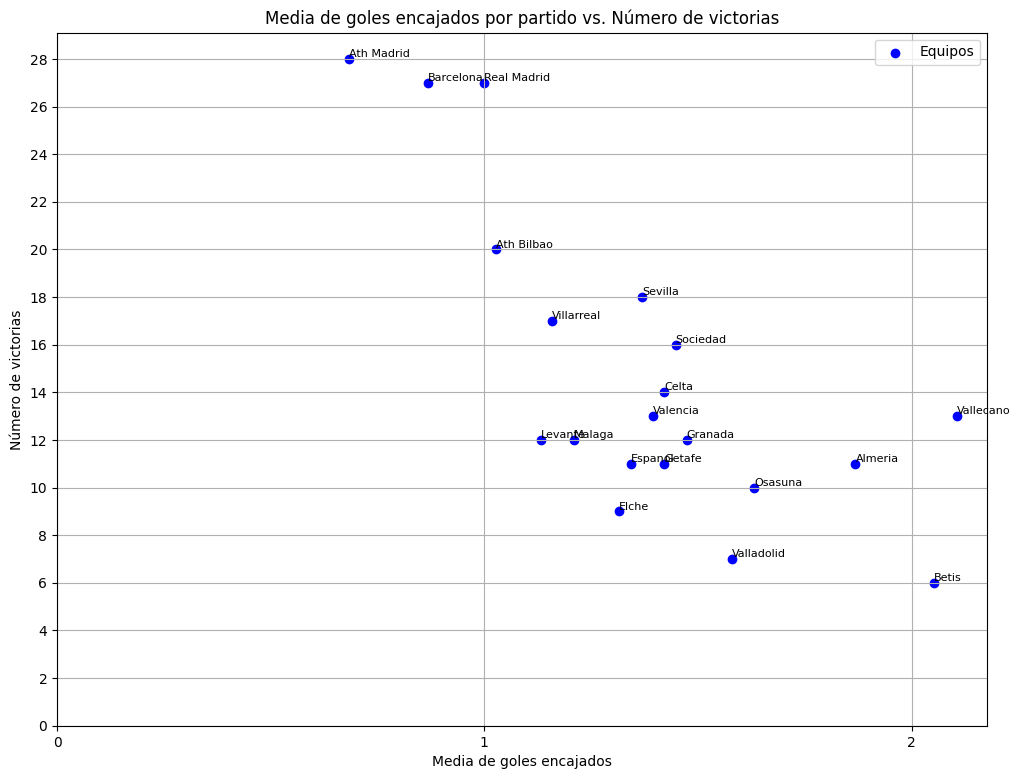

In [14]:
equipos = get_equipos(dataframe=dataframe_liga)
media_goles_encajados_todos_equipos = []
victorias_todos_equipos = []
for equipo in equipos:
    media_goles_encajados_todos_equipos.append(get_media_goles_encajados(dataframe=dataframe_liga, equipo=equipo))
    victorias_todos_equipos.append(get_victorias(dataframe=dataframe_liga, equipo=equipo))
maximos_goles = max(media_goles_encajados_todos_equipos)
maximas_victorias = max(victorias_todos_equipos)

plt.figure(figsize=(12, 9))
plt.scatter(media_goles_encajados_todos_equipos, victorias_todos_equipos, color='blue', label='Equipos')  # Puntos en la gráfica para cada equipo
for i, equipo in enumerate(equipos):
    plt.text(media_goles_encajados_todos_equipos[i], victorias_todos_equipos[i], equipo, fontsize=8, ha='left', va='bottom')
plt.xlabel('Media de goles encajados')
plt.ylabel('Número de victorias')
plt.title('Media de goles encajados por partido vs. Número de victorias')
plt.xticks(range(0, round(maximos_goles)+1, 1))  # Definir los límites y el paso del eje x
plt.yticks(range(0, maximas_victorias+1, 2))  # Definir los límites y el paso del eje y
plt.grid(True)
plt.legend()
plt.show()

### Cuarta aproximación: Media goles marcados - Media goles encajados

In [15]:
def get_media_goles_marcados_menos_encajados(dataframe: pd.DataFrame, equipo: str) -> float:
    goles_encajados = get_media_goles_encajados(dataframe=dataframe, equipo=equipo)
    goles_marcados = get_media_goles_marcados(dataframe=dataframe, equipo=equipo)
    return goles_marcados - goles_encajados

for equipo in equipos:
    media_goles_marcados_menos_encajados = get_media_goles_marcados_menos_encajados(dataframe=dataframe_liga, equipo=equipo)
    #print("El "+equipo+" tiene una media de goles marcados - encajados por partido de: "+str(media_goles_marcados_menos_encajados))

### Graficar datos

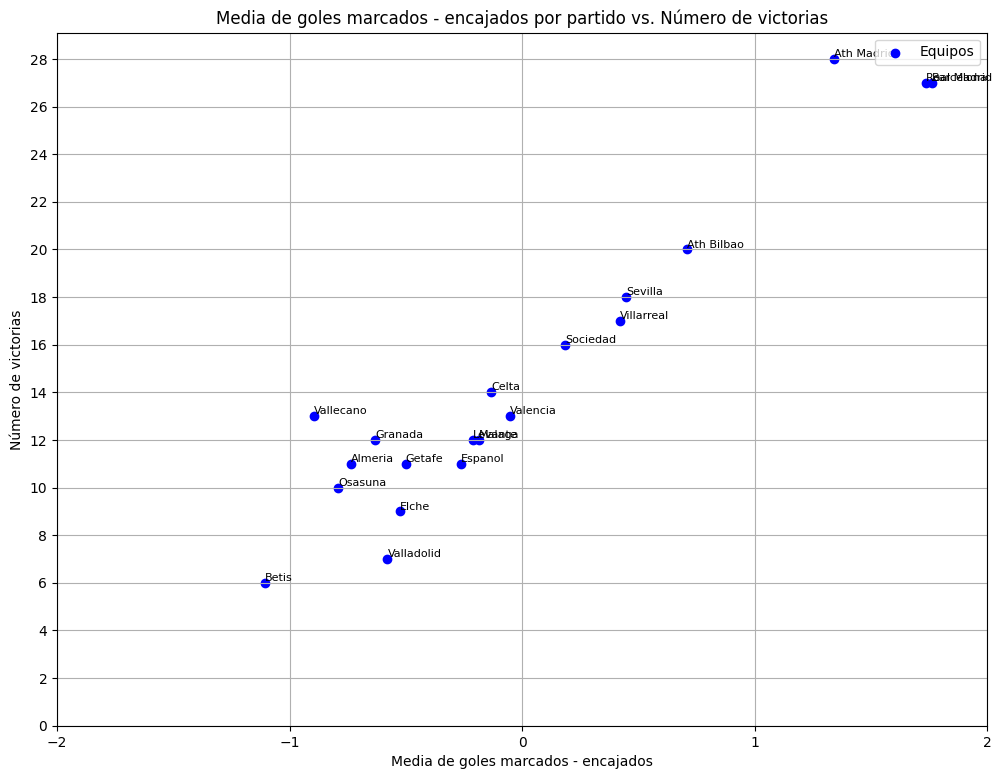

In [16]:
equipos = get_equipos(dataframe=dataframe_liga)
media_goles_marcados_menos_encajados_todos_equipos = []
victorias_todos_equipos = []
for equipo in equipos:
    media_goles_marcados_menos_encajados_todos_equipos.append(get_media_goles_marcados_menos_encajados(dataframe=dataframe_liga, equipo=equipo))
    victorias_todos_equipos.append(get_victorias(dataframe=dataframe_liga, equipo=equipo))
minimo_goles = min(media_goles_marcados_menos_encajados_todos_equipos)
maximos_goles = max(media_goles_marcados_menos_encajados_todos_equipos)
maximas_victorias = max(victorias_todos_equipos)

plt.figure(figsize=(12, 9))
plt.scatter(media_goles_marcados_menos_encajados_todos_equipos, victorias_todos_equipos, color='blue', label='Equipos')  # Puntos en la gráfica para cada equipo
for i, equipo in enumerate(equipos):
    plt.text(media_goles_marcados_menos_encajados_todos_equipos[i], victorias_todos_equipos[i], equipo, fontsize=8, ha='left', va='bottom')
plt.xlabel('Media de goles marcados - encajados')
plt.ylabel('Número de victorias')
plt.title('Media de goles marcados - encajados por partido vs. Número de victorias')
plt.xticks(range(round(minimo_goles)-1, round(maximos_goles)+1, 1))  # Definir los límites y el paso del eje x
plt.yticks(range(0, maximas_victorias+1, 2))  # Definir los límites y el paso del eje y
plt.grid(True)
plt.legend()
plt.show()

## Relevancia de Local o Visitante

### ¿Es importante el campo donde se juega?

In [17]:
def get_resultados_totales(dataframe: pd.DataFrame) -> list:
    victorias_local = len(dataframe.loc[dataframe['FTR'] == 'H'])
    empates = len(dataframe.loc[dataframe['FTR'] == 'D'])
    victorias_visitante = len(dataframe.loc[dataframe['FTR'] == 'A'])
    return (victorias_local,empates,victorias_visitante)

resultados = get_resultados_totales(dataframe=dataframe_liga)
#print("Victorias local: "+str(resultados[0]))
#print("Empates: "+str(resultados[1]))
#print("Victorias visitante: "+str(resultados[2]))

### Graficar datos

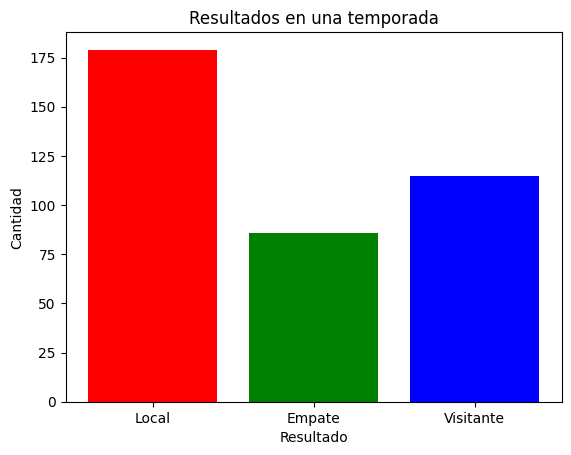

In [18]:
resultados = get_resultados_totales(dataframe=dataframe_liga)
variables = ['Local','Empate','Visitante']

plt.bar(variables, resultados, color=['red', 'green', 'blue'])

plt.xlabel('Resultado')
plt.ylabel('Cantidad')
plt.title('Resultados en una temporada')

plt.show()

## Importancia de las tarjetas rojas

In [19]:
def get_media_rojas(dataframe: pd.DataFrame, equipo: str) -> float:
    rojas_local = dataframe.loc[dataframe['HomeTeam'] == equipo, 'HR'].sum()
    rojas_visitante = dataframe.loc[dataframe['AwayTeam'] == equipo, 'AR'].sum()
    partidos_jugados = 2 * len(dataframe) / len(equipos)
    return (rojas_local + rojas_visitante) / partidos_jugados

for equipo in equipos:
    media_rojas = get_media_rojas(dataframe=dataframe_liga, equipo=equipo)
    #print("El "+equipo+" tiene una media de rojas de "+str(media_rojas))

### Graficar datos

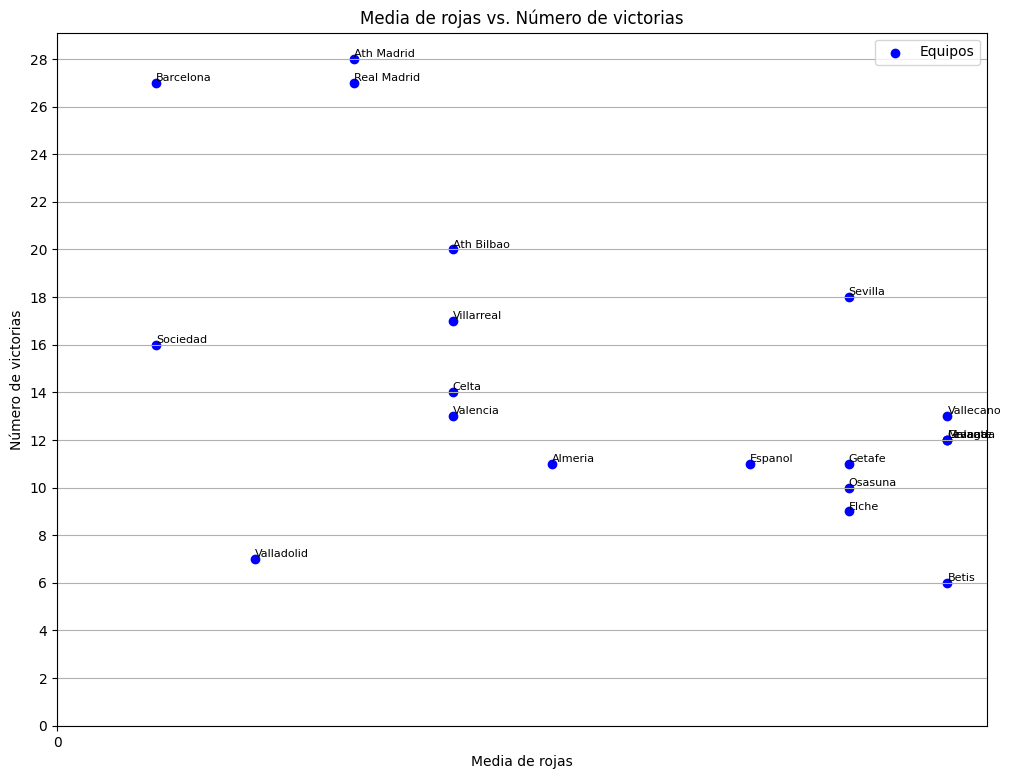

In [20]:
equipos = get_equipos(dataframe=dataframe_liga)
media_rojas_todos_equipos = []
victorias_todos_equipos = []
for equipo in equipos:
    media_rojas_todos_equipos.append(get_media_rojas(dataframe=dataframe_liga, equipo=equipo))
    victorias_todos_equipos.append(get_victorias(dataframe=dataframe_liga, equipo=equipo))
maximos_goles = max(media_rojas_todos_equipos)
maximas_victorias = max(victorias_todos_equipos)

plt.figure(figsize=(12, 9))
plt.scatter(media_rojas_todos_equipos, victorias_todos_equipos, color='blue', label='Equipos')  # Puntos en la gráfica para cada equipo
for i, equipo in enumerate(equipos):
    plt.text(media_rojas_todos_equipos[i], victorias_todos_equipos[i], equipo, fontsize=8, ha='left', va='bottom')
plt.xlabel('Media de rojas')
plt.ylabel('Número de victorias')
plt.title('Media de rojas vs. Número de victorias')
plt.xticks(range(0, round(maximos_goles)+1, 1))  # Definir los límites y el paso del eje x
plt.yticks(range(0, maximas_victorias+1, 2))  # Definir los límites y el paso del eje y
plt.grid(True)
plt.legend()
plt.show()

## Racha de victorias

In [21]:
def get_resultados_equipo(dataframe: pd.DataFrame, equipo=equipo) -> list:
    lista_resultados = []
    for idx, fila in dataframe.iterrows():
        if fila['HomeTeam'] == equipo:
            if fila['FTR'] == 'H':
                lista_resultados.append('W')
            elif fila['FTR'] == 'A':
                lista_resultados.append('D')
            else:
                lista_resultados.append('L')
        if fila['AwayTeam'] == equipo:
            if fila['FTR'] == 'A':
                lista_resultados.append('W')
            elif fila['FTR'] == 'H':
                lista_resultados.append('D')
            else:
                lista_resultados.append('L')
    return lista_resultados

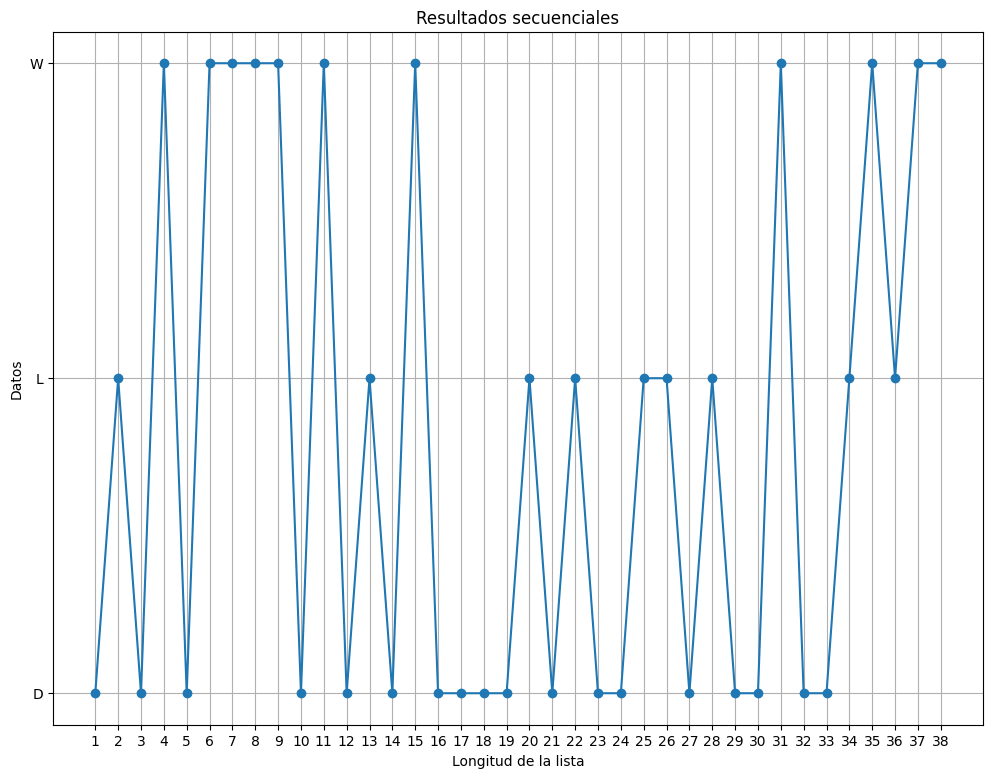

In [22]:
datos = get_resultados_equipo(dataframe=dataframe_liga, equipo="Getafe")
longitud = len(datos)
plt.figure(figsize=(12, 9))
plt.plot(range(1, longitud + 1), datos, marker='o')

plt.xticks(range(1, longitud + 1))

plt.xlabel('Longitud de la lista')
plt.ylabel('Datos')

plt.title('Resultados secuenciales')

# Mostrar la gráfica
plt.grid(True)
plt.show()